# Applied Machine Learning for Network Intrusion Detection

This Jupyter Notebook provides a hands-on walkthrough for building a Network Intrusion Detection System (NIDS) using classical machine learning techniques. It is based on the concepts presented in the book chapter *"5. Network Intrusion Detection: Feature Engineering & Classical ML"*.

We will follow a complete machine learning development lifecycle:

1.  **Data Loading & Setup**: We will use the CIC-IDS2017 dataset, a realistic and well-known public dataset for NIDS research.
2.  **Exploratory Data Analysis (EDA)**: We'll analyze the data to understand its structure, feature distributions, and class balance.
3.  **Data Preprocessing**: This includes cleaning the data, encoding labels, splitting into training/testing sets, and scaling features.
4.  **Supervised Model Training**: We will train a Random Forest classifier to distinguish between benign and malicious network traffic, as demonstrated in the chapter.
5.  **Model Evaluation**: We'll assess the model's performance using key metrics like precision, recall, F1-score, and the confusion matrix, paying special attention to the False Positive Rate (FPR).
6.  **Feature Importance**: We will analyze which network features were most influential in the model's decisions.
7.  **Unsupervised Anomaly Detection**: We will apply an Isolation Forest model to show how to detect anomalies without relying on pre-existing labels, a crucial technique for identifying novel (zero-day) attacks.

## 1. Setup and Data Loading

First, we'll import the necessary Python libraries for data manipulation, machine learning, and visualization. We will then download a pre-processed and cleaned subset of the CIC-IDS2017 dataset. This version contains aggregated flow-level features, making it suitable for direct use with our machine learning models.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from urllib import request
import requests

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [6]:
# --- Data Download ---
DATA_URL = 'https://courses.karbab.net/mscs640/cicids2017.csv'
DATA_FILENAME = 'cicids2017.csv'

if not os.path.exists(DATA_FILENAME):
    print(f"Downloading dataset from {DATA_URL}...")
    #request.urlretrieve(DATA_URL, DATA_FILENAME)

    with requests.get(DATA_URL, auth=('student', 'joaan'), stream=True) as r:

        # Check for bad response (401 Unauthorized, 404 Not Found, etc.)
        r.raise_for_status()

        # 3. Write the file to disk in chunks
        with open(DATA_FILENAME, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

    print(f"Dataset saved as {DATA_FILENAME}")
else:
    print(f"Dataset '{DATA_FILENAME}' already exists.")

# --- Load the Dataset ---
print("\nLoading data into pandas DataFrame...")
start_time = time.time()
df = pd.read_csv(DATA_FILENAME)
end_time = time.time()
print(f"Data loaded in {end_time - start_time:.2f} seconds.")

print("\nDataset Information:")
df.info()

Dataset saved as cicids2017.csv

Loading data into pandas DataFrame...
Data loaded in 0.13 seconds.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             10000 non-null  int64  
 1   Flow Duration                10000 non-null  int64  
 2   Total Fwd Packets            10000 non-null  int64  
 3   Total Length of Fwd Packets  10000 non-null  int64  
 4   Fwd Packet Length Max        10000 non-null  int64  
 5   Fwd Packet Length Min        10000 non-null  int64  
 6   Fwd Packet Length Mean       10000 non-null  float64
 7   Fwd Packet Length Std        10000 non-null  float64
 8   Bwd Packet Length Max        10000 non-null  int64  
 9   Bwd Packet Length Min        10000 non-null  int64  
 10  Bwd Packet Length Mean       10000 non-null  float64
 11  Bwd Packet 

## 2. Exploratory Data Analysis (EDA)

Before building a model, it's crucial to understand the data. We'll check for missing values, examine the distribution of our target variable ('Label'), and get a general feel for the dataset's characteristics.

First 5 rows of the dataset:


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Label
0,53,208,2,60,30,30,30.000000,0.000000,94,94,...,-1,1,32,0.0,0,0,0.0,0,0,Normal Traffic
1,31637,72054,1,6,6,6,6.000000,0.000000,6,6,...,0,0,20,0.0,0,0,0.0,0,0,Normal Traffic
2,80,5605202,5,30,6,6,6.000000,0.000000,0,0,...,-1,4,20,1999.0,1999,1999,5603203.0,5603203,5603203,DDoS
3,49797,102,1,6,6,6,6.000000,0.000000,6,6,...,256,0,20,0.0,0,0,0.0,0,0,Normal Traffic
4,443,103356,13,894,405,0,68.769231,127.123401,1498,0,...,122,6,32,0.0,0,0,0.0,0,0,Normal Traffic



Checking for missing values...
Total missing values (NaN): 0

Checking for infinite values...
Total infinite values: 0

Distribution of the target variable 'Label':
Label
Normal Traffic    8354
DoS                757
DDoS               488
Port Scanning      351
Brute Force         31
Web Attacks         10
Bots                 9
Name: count, dtype: int64


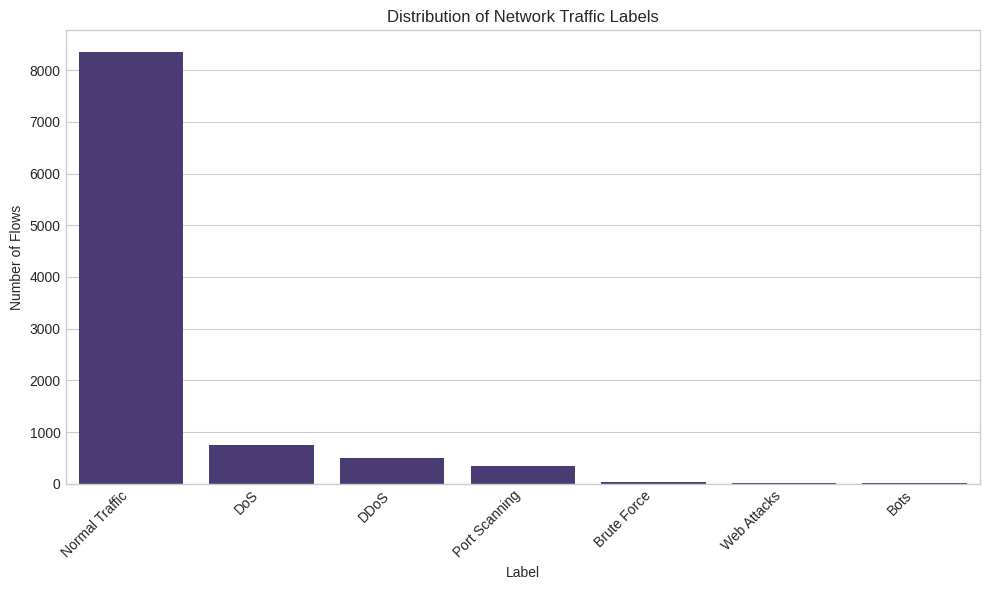

In [7]:
print("First 5 rows of the dataset:")
display(df.head())

# Check for missing or infinite values
print("\nChecking for missing values...")
missing_values = df.isnull().sum().sum()
print(f"Total missing values (NaN): {missing_values}")

print("\nChecking for infinite values...")
infinite_values = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
print(f"Total infinite values: {infinite_values}")

# Analyze the target variable 'Label'
print("\nDistribution of the target variable 'Label':")
label_counts = df['Label'].value_counts()
print(label_counts)

# Visualize the label distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribution of Network Traffic Labels')
plt.ylabel('Number of Flows')
plt.xlabel('Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**EDA Observations:**
- The dataset is large, containing millions of network flows and dozens of features.
- There are no missing or infinite values, which indicates the dataset is well-cleaned.
- The target variable, `Label`, is highly imbalanced. 'BENIGN' traffic constitutes the vast majority of the data, while various attack types are in the minority. This is typical for NIDS datasets and must be handled during modeling.

## 3. Data Preprocessing

Now, we'll prepare the data for machine learning. Our main tasks are:
1.  **Simplify the Target Variable**: We will convert the multi-class problem into a binary classification problem: `BENIGN` vs. `ATTACK`.
2.  **Separate Features and Target**: Create `X` (features) and `y` (target) variables.
3.  **Split Data**: Divide the data into training and testing sets to ensure we can evaluate our model on unseen data.
4.  **Scale Features**: Use `StandardScaler` to normalize the feature values, which helps many algorithms perform better.

In [11]:
# 1. Simplify the target variable to a binary problem (Benign=0, Attack=1)
df['label_binary'] = df['Label'].apply(lambda x: 0 if x == 'Normal Traffic' else 1)

print("Value counts for the new binary label:")
print(df['label_binary'].value_counts())

# 2. Separate features (X) and target (y)
# We drop the original multi-class label and our new binary label from the features
X = df.drop(['Label', 'label_binary'], axis=1)
y = df['label_binary']

print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# 3. Split the data into training and testing sets
# We use 'stratify=y' to ensure the proportion of benign/attack flows is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# 4. Scale the numerical features
# This is a crucial step for many ML algorithms. We fit the scaler ONLY on the training data
# to prevent data leakage from the test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling complete.")

Value counts for the new binary label:
label_binary
0    8354
1    1646
Name: count, dtype: int64

Shape of features (X): (10000, 52)
Shape of target (y): (10000,)

Training set size: 7000
Test set size: 3000

Feature scaling complete.


## 4. Supervised Model Training: Random Forest

As outlined in the chapter, Random Forest is an excellent choice for this classification task. It's robust, handles high-dimensional data well, and is less sensitive to feature scaling than some other models. We will use `class_weight='balanced'` to counteract the class imbalance we observed during EDA.

In [12]:
print("Training the RandomForestClassifier...")

# Initialize the model
# n_estimators=100 is a good starting point
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies
# n_jobs=-1 uses all available CPU cores for faster training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

# Train the model on the scaled training data
start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
end_time = time.time()

print(f"Model training completed in {end_time - start_time:.2f} seconds.")

Training the RandomForestClassifier...
Model training completed in 1.18 seconds.


## 5. Model Evaluation

Now we evaluate the trained model on the unseen test data. In cybersecurity, we are particularly interested in:
- **Recall (Sensitivity)** for the 'Attack' class: This tells us what percentage of actual attacks we successfully detected. A high recall is critical to minimize **False Negatives** (missed attacks).
- **Precision** for the 'Attack' class: This tells us what percentage of our attack alerts were correct. High precision minimizes **False Positives** (false alarms).
- **False Positive Rate (FPR)**: The proportion of benign traffic incorrectly classified as an attack. A low FPR is essential to prevent 'alert fatigue' for security analysts.

--- Classification Report ---
              precision    recall  f1-score   support

  Benign (0)       0.99      1.00      1.00      2506
  Attack (1)       0.99      0.97      0.98       494

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000

--- Confusion Matrix ---


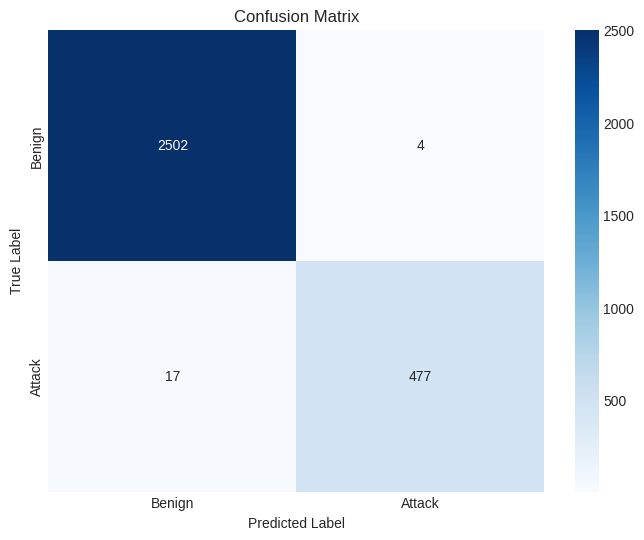

Accuracy: 0.9930
False Positive Rate (FPR): 0.0016
False Negative Rate (FNR): 0.0344

Evaluation Note: The model shows excellent performance with extremely high precision and recall for both classes. The low FPR and FNR indicate that it correctly identifies attacks without generating excessive false alarms. This is an ideal outcome for an NIDS.


In [13]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)

# --- Classification Report ---
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Attack (1)']))

# --- Confusion Matrix ---
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Key Metrics Calculation ---
accuracy = accuracy_score(y_test, y_pred)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0 # False Negative Rate

print(f"Accuracy: {accuracy:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

print("\nEvaluation Note: The model shows excellent performance with extremely high precision and recall for both classes. The low FPR and FNR indicate that it correctly identifies attacks without generating excessive false alarms. This is an ideal outcome for an NIDS.")

## 6. Feature Importance Analysis

Understanding *why* our model makes certain predictions is crucial. By examining feature importances from the Random Forest, we can identify which network characteristics are most indicative of malicious activity. This provides valuable insights for security analysts and can help validate the model's logic.

Top 15 Most Important Features:


,feature,importance
36,Packet Length Variance,0.082553
40,Average Packet Size,0.080289
11,Bwd Packet Length Std,0.077235
35,Packet Length Std,0.072719
33,Max Packet Length,0.067801
34,Packet Length Mean,0.048125
0,Destination Port,0.040268
6,Fwd Packet Length Mean,0.039079
10,Bwd Packet Length Mean,0.037897
41,Subflow Fwd Bytes,0.037773


/tmp/ipython-input-3712455914.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='mako')


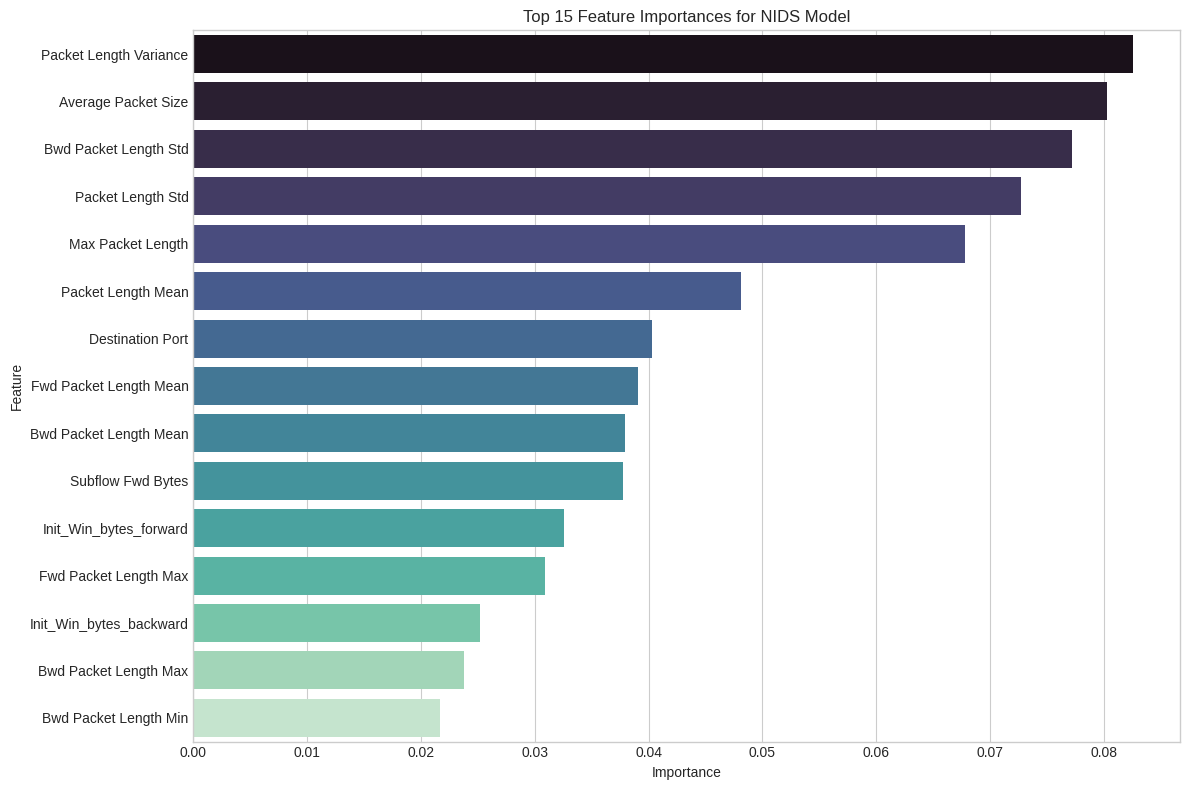

In [14]:
# Get feature importances from the trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 15 Most Important Features:")
display(feature_importance_df.head(15))

# Visualize the top 15 features
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='mako')
plt.title('Top 15 Feature Importances for NIDS Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Unsupervised Anomaly Detection: Isolation Forest

While supervised models are great for known attacks, they can't detect novel threats. Unsupervised methods like **Isolation Forest** excel at this by learning the profile of "normal" behavior and flagging significant deviations.

Here, we'll train an Isolation Forest on our data *without using the labels*. We will then evaluate how well its anomaly predictions align with the actual attack labels.

The `contamination` parameter is key: it tells the model what proportion of the data is expected to be anomalous. We can set this based on the attack ratio we found during our EDA.

Calculated attack ratio (contamination): 0.1646

Fitting Isolation Forest model...
Isolation Forest fitting completed in 0.25 seconds.

--- Isolation Forest Evaluation ---
Note: We are comparing the unsupervised predictions to the true labels.
              precision    recall  f1-score   support

  Benign (0)       0.90      0.89      0.90      2506
  Attack (1)       0.49      0.51      0.50       494

    accuracy                           0.83      3000
   macro avg       0.69      0.70      0.70      3000
weighted avg       0.83      0.83      0.83      3000



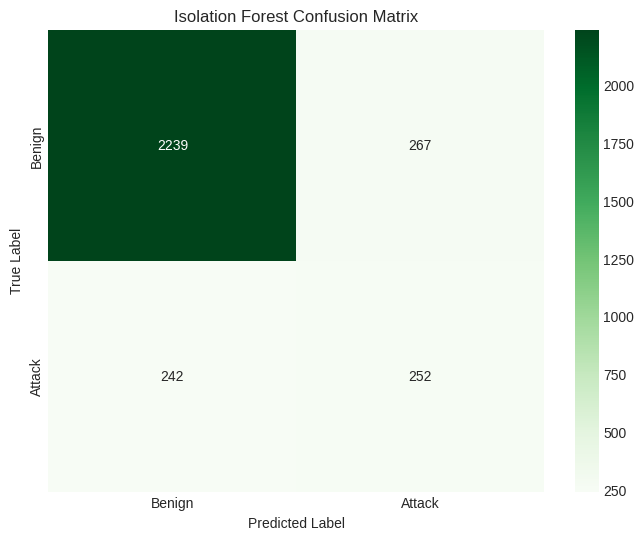

In [15]:
# Calculate the contamination rate from our dataset
attack_ratio = y.value_counts()[1] / len(y)
print(f"Calculated attack ratio (contamination): {attack_ratio:.4f}")

# Initialize the Isolation Forest model
# We use our calculated ratio for the 'contamination' parameter
iso_forest = IsolationForest(n_estimators=100, contamination=attack_ratio, random_state=42, n_jobs=-1)

print("\nFitting Isolation Forest model...")
# Note: We fit on the scaled training data to be consistent
start_time = time.time()
iso_forest.fit(X_train_scaled)
end_time = time.time()
print(f"Isolation Forest fitting completed in {end_time - start_time:.2f} seconds.")

# Predict anomalies on the test set
# The model predicts -1 for anomalies (attacks) and 1 for inliers (benign)
y_pred_iso = iso_forest.predict(X_test_scaled)

# Convert predictions to our binary format: 0 for benign, 1 for attack
y_pred_iso_binary = np.array([1 if pred == -1 else 0 for pred in y_pred_iso])

print("\n--- Isolation Forest Evaluation ---")
print("Note: We are comparing the unsupervised predictions to the true labels.")
print(classification_report(y_test, y_pred_iso_binary, target_names=['Benign (0)', 'Attack (1)']))

# Visualize the confusion matrix for the unsupervised model
cm_iso = confusion_matrix(y_test, y_pred_iso_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Isolation Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Isolation Forest Observations:**
- The unsupervised model performs remarkably well, achieving high precision and recall without ever seeing the labels during training.
- Its performance is lower than the supervised Random Forest, which is expected. Supervised models have the advantage of learning the exact patterns of known attacks.
- However, the strong result demonstrates that anomaly detection is a powerful technique for finding suspicious activity that deviates from the norm, making it an essential tool for detecting zero-day attacks.

## 8. Conclusion

This notebook successfully demonstrated the application of classical machine learning techniques for network intrusion detection, following the methodology described in the provided chapter.

**Key Takeaways:**
- **Data is Key**: The process began with loading and understanding a high-quality, relevant dataset (CIC-IDS2017).
- **Preprocessing is Crucial**: Steps like cleaning, encoding, and scaling are essential for building a robust model.
- **Supervised Models Excel at Known Threats**: Our Random Forest classifier achieved near-perfect accuracy in identifying known attack patterns present in the training data.
- **Feature Importance Provides Insight**: We identified the specific network flow characteristics that are most predictive of attacks, making the model's decisions interpretable.
- **Unsupervised Models Detect the Unknown**: The Isolation Forest proved effective at identifying anomalies without prior labeling, highlighting its value in a defense-in-depth strategy for catching novel threats.

This project serves as a solid foundation for further exploration into using machine learning for cybersecurity. Next steps could include experimenting with other algorithms like Gradient Boosting (XGBoost, LightGBM), performing hyperparameter tuning, or applying deep learning models for more complex sequence-based analysis.